In [1]:
import requests
import io
from bs4 import BeautifulSoup as BS

import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('ggplot')

In [2]:
r = requests.get("https://www.starsonata.com/wiki/index.php/Energies")

parsed = BS(r.content, 'html.parser')

# print(parsed.prettify)
tables = parsed.find_all("table")

In [5]:
df = pd.read_html(io.StringIO(str(tables[0])))[0]

In [6]:
df

,TL,Name,Size,Weight,Bank,Reg/s,Fuel / Waste,Fuel Time,Mods,Restrictions,Source,Description
0,0,Arcadian Energy,18,36000,780,107.50,NaN,NaN,Damage +20%,NaN,"AI Base -- 234,000",large-scale power
1,0,Cadet Energybank,10,10000,1500,75.00,NaN,NaN,"Shield Max +10%, Shield Recovery +10%",Neurobound,"Cadet Academy -- 5,000",A Cadet's favorite energy delivery and storage...
2,0,Core Power,10,20000,500,125.00,NaN,NaN,Electric Tempering -20%,NaN,"AI Base -- 64,900",expensive low-tech energy
3,0,Core Power+,9,18000,525,130.83,NaN,NaN,Electric Tempering -20%,NaN,"AI Base -- 649,000",expensive low-tech energy
4,0,Flux Capacitor,6,4500,610,83.33,NaN,NaN,"Shield Max +10%, Shield Recovery +10%",NaN,"AI Base -- 12,300",1 point 21 gigawatts
...,...,...,...,...,...,...,...,...,...,...,...,...
419,23,The Pumper,146,584000,11900,1065.83,NaN,NaN,"Shield Max +20%, Electric Tempering -25%",Requires 23 in Piracy,The Pumper Blueprint,Its time to get pumped up.
420,23,Uplifted Charge Cluster,263,394500,20600,825.83,NaN,NaN,"Shield Recovery +30%, Tractor Power +20%",NaN,Ruined Sanctuary drop,Flickering unknown power
421,23,Warlord's Bank,432,864000,77100,417.50,NaN,NaN,"Range +20%, Radar +50%, Hostility +30%, Resist...",Requires 23 in Piracy,Warlord's Bank Blueprint,The path to violence is paved with violence
422,23,Wondrous Shifting Scintillating Dynamo,251,502000,19700,789.16,NaN,NaN,"Rate of Fire +20%, Tracking +40%",NaN,Lumination boss and miniboss drop,Bang things around a bit


In [7]:
df_tl_reg = df.groupby('TL', as_index=False)['Reg/s'].agg(['min', 'max', 'mean', 'std'])
df_tl_bank = df.groupby("TL", as_index=False)['Bank'].agg(['min', 'max', 'mean', 'std'])

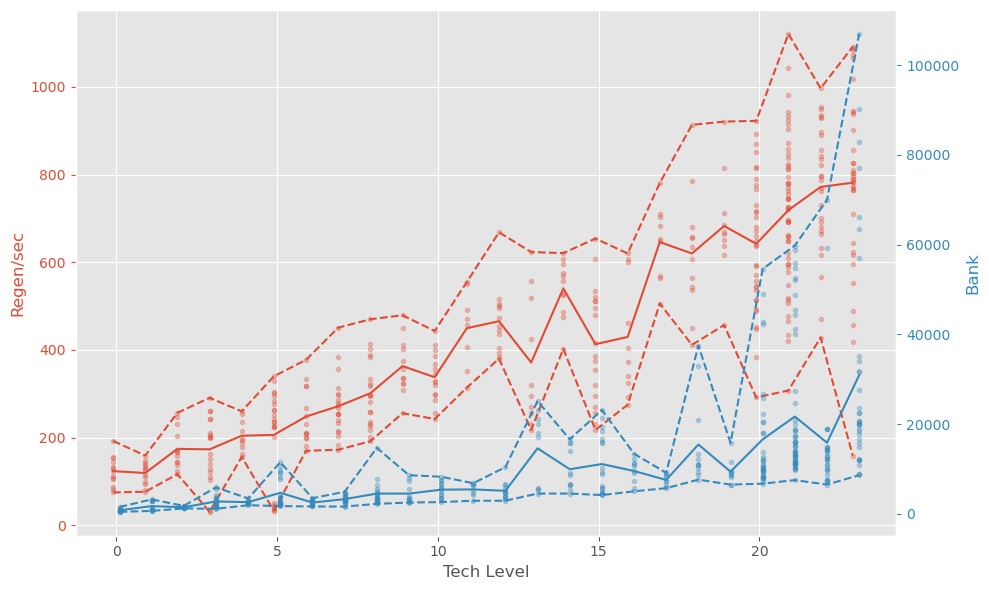

In [19]:
f, ax = plt.subplots(figsize=(10, 6))

ax.plot(df['TL']-0.1, df['Reg/s'], '.', alpha=0.3)
ax.plot(df_tl_reg['TL']-0.1, df_tl_reg['mean'], color='C0')
ax.plot(df_tl_reg['TL']-0.1, df_tl_reg['min'], '--', color='C0')
ax.plot(df_tl_reg['TL']-0.1, df_tl_reg['max'], '--', color='C0')

axx = ax.twinx()
axx.grid(False)
axx.plot(df['TL'] +0.1, df['Bank'], '.', color='C1', alpha=0.3)

axx.plot(df_tl_bank['TL']+0.1, df_tl_bank['mean'], color='C1')
axx.plot(df_tl_bank['TL']+0.1, df_tl_bank['min'], '--', color='C1')
axx.plot(df_tl_bank['TL']+0.1, df_tl_bank['max'], '--', color='C1')

axx.yaxis.label.set_color('C1')
axx.tick_params(axis='y', colors='C1')
axx.set_ylabel("Bank")

ax.tick_params(axis='y', colors='C0')
ax.set_ylabel("Regen/sec", color='C0')
ax.set_xlabel("Tech Level")
f.tight_layout()

In [49]:
df_tl_reg['delta_reg'] = df_tl_reg.loc[:, ['max']].diff()['max']
df_tl_reg['perc_reg'] = df_tl_reg['delta_reg'] / df_tl_reg['max'].shift(1)

df_tl_bank['delta_bank'] = df_tl_bank.loc[:, ['max']].diff()['max']
df_tl_bank['perc_bank'] = df_tl_bank['delta_bank'] / df_tl_bank['max'].shift(1)

In [50]:
df_tl_bank

,TL,min,max,mean,std,delta_bank,perc_bank
0,0,425,1500,762.307692,332.419260,NaN,NaN
1,1,630,3200,1703.307692,1055.997821,1700.0,1.133333
2,2,1190,1750,1444.538462,195.574630,-1450.0,-0.453125
3,3,1100,5880,2744.157895,1364.469016,4130.0,2.360000
4,4,1900,3400,2577.000000,462.776644,-2480.0,-0.421769
5,5,1700,11500,4664.347826,3343.231733,8100.0,2.382353
6,6,1615,3465,2488.928571,622.446101,-8035.0,-0.698696
7,7,1600,4900,3254.250000,910.695620,1435.0,0.414141
8,8,2200,14700,4495.950000,2791.014086,9800.0,2.000000
9,9,2500,8600,4485.416667,2243.436344,-6100.0,-0.414966


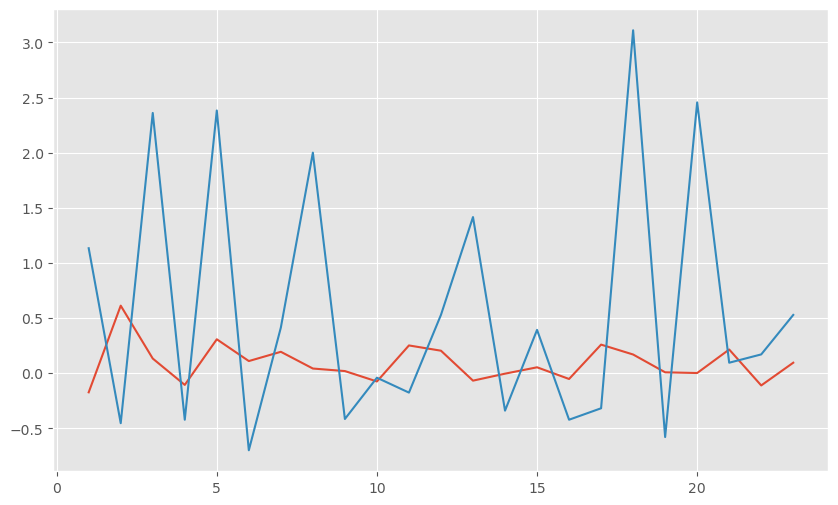

In [51]:
f, ax = plt.subplots(figsize=(10, 6))
ax.plot(df_tl_reg['TL'], df_tl_reg['perc_reg'])
ax.plot(df_tl_bank['TL'], df_tl_bank['perc_bank'])

In [ ]:
s